In [17]:
import pandas as pd

tweets_a = pd.read_csv("test_a_tweets_all.tsv", sep="\t")
tweets_b = pd.read_csv("test_b_tweets_all.tsv", sep="\t")
tweets_c = pd.read_csv("test_c_tweets_all.tsv", sep="\t")

labels_a = pd.read_csv("test_a_labels_all.csv")
labels_b = pd.read_csv("test_b_labels_all.csv")
labels_c = pd.read_csv("test_c_labels_all.csv")

data_a = tweets_a.merge(labels_a, on="id")
data_a.rename(columns={"tweet": "text", "label": "label_A"}, inplace=True)

data_b = tweets_b.merge(labels_b, on="id")
data_b.rename(columns={"label": "label_B"}, inplace=True)

data_c = tweets_c.merge(labels_c, on="id")
data_c.rename(columns={"label": "label_C"}, inplace=True)

df = data_a.merge(data_b[["id", "label_B"]], on="id", how="left")
df = df.merge(data_c[["id", "label_C"]], on="id", how="left")

print(df.head())

   id                                               text label_A label_B  \
0  B0  Has @USER quit? I've not heard of any #knifecr...     NOT     NaN   
1  B1  In celebration of Emancipation Day, we urge yo...     NOT     NaN   
2  B2  @USER @USER It’d be a literal dream come true ...     NOT     NaN   
3  B3  Brilliant news to read that Hoggy has signed a...     NOT     NaN   
4  B4                    @USER She speaks of the truth 😌     NOT     NaN   

  label_C  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  


In [18]:
# NOT NULL NULL
cond1 = (df['label_A'] == 'NOT') & (df['label_B'].isna()) & (df['label_C'].isna())

# OFF UNT NULL
cond2 = (df['label_A'] == 'OFF') & (df['label_B'] == 'UNT') & (df['label_C'].isna())

# OFF TIN (IND|GRP|OTH)
cond3 = (df['label_A'] == 'OFF') & (df['label_B'] == 'TIN') & (df['label_C'].isin(['IND', 'GRP', 'OTH']))

In [19]:
print("NOT NULL NULL:", cond1.sum())
print("OFF UNT NULL:", cond2.sum())
print("OFF TIN (IND|GRP|OTH):", cond3.sum())

NOT NULL NULL: 2991
OFF UNT NULL: 1452
OFF TIN (IND|GRP|OTH): 1546


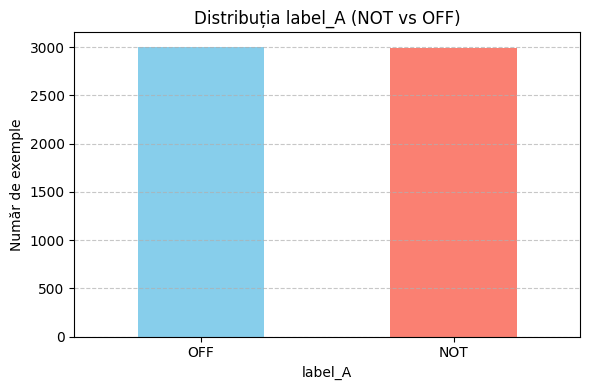

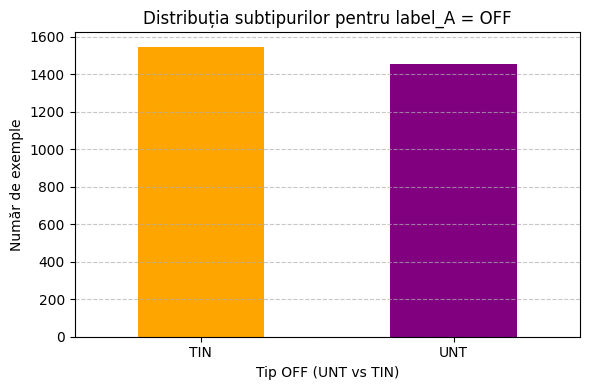

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Creează o copie doar pentru curățare temporară
df_temp = df.copy()

for col in ['label_A', 'label_B', 'label_C']:
    df_temp[col] = df_temp[col].astype(str).str.strip().replace("nan", pd.NA)

counts_a = df_temp['label_A'].value_counts()

plt.figure(figsize=(6,4))
counts_a.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Distribuția label_A (NOT vs OFF)")
plt.ylabel("Număr de exemple")
plt.xlabel("label_A")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

off_subtype = pd.Series(pd.NA, index=df_temp.index)

off_subtype[(df_temp['label_A'] == 'OFF') & 
            (df_temp['label_B'] == 'UNT') & 
            (df_temp['label_C'].isna())] = 'UNT'

off_subtype[(df_temp['label_A'] == 'OFF') & 
            (df_temp['label_B'] == 'TIN') & 
            (df_temp['label_C'].isin(['IND', 'GRP', 'OTH']))] = 'TIN'

counts_off = off_subtype.value_counts()

plt.figure(figsize=(6,4))
counts_off.plot(kind='bar', color=['orange', 'purple'])
plt.title("Distribuția subtipurilor pentru label_A = OFF")
plt.ylabel("Număr de exemple")
plt.xlabel("Tip OFF (UNT vs TIN)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [23]:
df.to_csv("../OLID.csv", index=False)